# Data Loading and Exploration

**PTB-XL 12-lead ECG dataset.** This is the entry point of the project pipeline. The
downstream stages (preprocessing, baseline CNN, transformer fine-tuning, leadwise
transformer, explainability, uncertainty, and the Streamlit clinical demo) all
depend on the structures defined here, so this notebook focuses on three things:

1. **Document the dataset** - what PTB-XL contains, how it is laid out on disk, and
   how labels are organised.
2. **Demonstrate the codebase API** - we use `src/preprocessing/label_utils.py` and the
   `CFG` singleton so the notebook matches what `src/preprocessing/dataset.py` does at
   training time. No hardcoded paths.
3. **Persist artifacts for downstream use** - a `dataset_summary.json` with class
   counts and split sizes, an `example_records.json` mapping each superclass to a
   representative `ecg_id`, and saved figures. These are consumed by later
   notebooks and by the Streamlit app under `app/`.

We use the **low-resolution variant** (100 Hz, 10 s, 12 leads -> shape `(1000, 12)`)
throughout. The high-resolution 500 Hz variant is not used.

## 1. Environment setup

We import the project's `CFG` singleton, which resolves all paths to absolute
values relative to the project root (see `src/utils/config.py`). This means the
notebook works regardless of the working directory Jupyter was launched from.

In [1]:
import sys, os
from pathlib import Path

# Make `src` importable when running from notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import CFG

DATA_PATH    = CFG['data']['path']
RESULTS_PATH = CFG['paths']['results']
FIGURES_PATH = CFG['paths']['figures']

print(f"Project root : {PROJECT_ROOT}")
print(f"Data path    : {DATA_PATH}")
print(f"Sampling rate: {CFG['data']['sampling_rate']} Hz")
print(f"Window size  : {CFG['data']['window_size']} samples ({CFG['data']['window_size'] / CFG['data']['sampling_rate']:.1f} s)")
print(f"Stride       : {CFG['data']['stride']} samples")
print(f"Superclasses : {CFG['data']['superclasses']}")

Project root : D:\GitHub\biosignal-xai
Data path    : D:\GitHub\biosignal-xai\data/
Sampling rate: 100 Hz
Window size  : 250 samples (2.5 s)
Stride       : 125 samples
Superclasses : ['NORM', 'MI', 'STTC', 'CD', 'HYP']


### Data availability check

Both metadata CSVs (`ptbxl_database.csv`, `scp_statements.csv`) and the WFDB signal
folders (`records100/`) must be present under `data/`. If anything is missing the
next cell prints what to do.

In [2]:
csv_db  = Path(DATA_PATH) / 'ptbxl_database.csv'
csv_scp = Path(DATA_PATH) / 'scp_statements.csv'
records_dir = Path(DATA_PATH) / 'records100'

missing = [p for p in [csv_db, csv_scp, records_dir] if not p.exists()]
if missing:
    print('Missing data artifacts:')
    for p in missing:
        print(f'  - {p}')
    print('\nDownload PTB-XL v1.0.3 from PhysioNet:')
    print('  https://physionet.org/content/ptb-xl/1.0.3/')
else:
    n_subdirs = sum(1 for d in records_dir.iterdir() if d.is_dir())
    print('All data artifacts present.')
    print(f'  ptbxl_database.csv : {csv_db.stat().st_size / 1024:.0f} KB')
    print(f'  scp_statements.csv : {csv_scp.stat().st_size / 1024:.0f} KB')
    print(f'  records100/        : {n_subdirs} subfolders')

All data artifacts present.
  ptbxl_database.csv : 6440 KB
  scp_statements.csv : 9 KB
  records100/        : 22 subfolders


## 2. (Optional) Acquiring PTB-XL

If the data are missing the cell below scrapes the PhysioNet directory listing for
the low-resolution records. It is **guarded by an `if False`** and will only run
when the flag is flipped. Skip this section entirely once the data are on disk.

Required packages: `wfdb`, `requests`, `beautifulsoup4`, `tqdm` (already pinned
in `environment.yml` / `requirements.txt`).

In [3]:
RUN_DOWNLOAD = False  # flip to True only the first time

if RUN_DOWNLOAD:
    import requests, urllib3
    from bs4 import BeautifulSoup
    from tqdm import tqdm

    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

    BASE = 'https://physionet.org/files/ptb-xl/1.0.3/'
    save_root = Path(DATA_PATH) / 'records100'
    save_root.mkdir(parents=True, exist_ok=True)

    # CSV metadata
    for name in ('ptbxl_database.csv', 'scp_statements.csv'):
        out = Path(DATA_PATH) / name
        if not out.exists():
            out.write_bytes(requests.get(BASE + name, verify=False).content)
            print(f'Saved {out.name}')

    # Signal folders: 00000, 01000, ..., 21000
    folders = [f'{i:05d}' for i in range(0, 22000, 1000)]
    session = requests.Session(); session.verify = False
    for folder in tqdm(folders, desc='Folders'):
        folder_url = f'{BASE}records100/{folder}/'
        local = save_root / folder
        local.mkdir(exist_ok=True)
        html = session.get(folder_url).text
        files = [a['href'] for a in BeautifulSoup(html, 'html.parser').find_all('a')
                 if a['href'].endswith(('.dat', '.hea'))]
        for fn in files:
            target = local / fn
            if target.exists():
                continue
            target.write_bytes(session.get(folder_url + fn).content)
    print('Download complete.')
else:
    print('Skipped (RUN_DOWNLOAD = False).')

Skipped (RUN_DOWNLOAD = False).


## 3. Metadata: `ptbxl_database.csv`

One row per ECG recording (21,799 rows) with 28 columns. The columns we care about
downstream are:

- `ecg_id` (index) - unique recording identifier.
- `patient_id` - same patient may contribute multiple recordings (we keep the
  PTB-XL split, which is patient-stratified, so leakage is avoided).
- `filename_lr` - path to the WFDB record relative to `data/`.
- `scp_codes` - stringified `dict` of `{code: likelihood}`. Likelihood `100`
  means confident, `0` means present but unconfirmed.
- `strat_fold` - integer 1-10. The reproducible PTB-XL split is folds 1-8 train,
  fold 9 validation, fold 10 test.
- `age`, `sex` - demographics. Age `300` is the placeholder for missing.
  Sex is `0 = Male`, `1 = Female`.

In [4]:
import pandas as pd
import ast

db = pd.read_csv(DATA_PATH + 'ptbxl_database.csv', index_col='ecg_id')
db['scp_codes'] = db['scp_codes'].apply(ast.literal_eval)

print(f'Total records : {len(db):,}')
print(f'Total patients: {db["patient_id"].nunique():,}')
print(f'Columns ({len(db.columns)}): {list(db.columns)}')
db.head(3)

Total records : 21,799
Total patients: 18,869
Columns (27): ['patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human', 'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr']


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr


### 3.1 Demographics

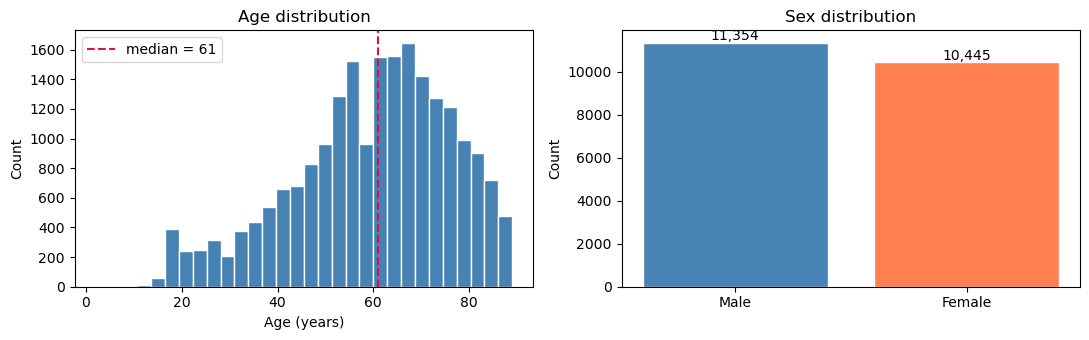

Age (valid only): mean = 59.5, std = 16.8, range = [2, 89]
Missing age placeholder (300): 293


In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# Age - exclude placeholder 300
age_valid = db.loc[db['age'] < 300, 'age']
axes[0].hist(age_valid, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(age_valid.median(), color='crimson', linestyle='--',
                label=f'median = {age_valid.median():.0f}')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].set_title('Age distribution')
axes[0].legend()

# Sex
sex_counts = db['sex'].map({0: 'Male', 1: 'Female'}).value_counts()
axes[1].bar(sex_counts.index, sex_counts.values,
            color=['steelblue', 'coral'], edgecolor='white')
for i, v in enumerate(sex_counts.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center')
axes[1].set_ylabel('Count')
axes[1].set_title('Sex distribution')

plt.tight_layout()
plt.show()

print(f'Age (valid only): mean = {age_valid.mean():.1f}, std = {age_valid.std():.1f}, '
      f'range = [{age_valid.min():.0f}, {age_valid.max():.0f}]')
print(f'Missing age placeholder (300): {(db["age"] == 300).sum()}')

### 3.2 Stratified folds (the standard PTB-XL split)

The `strat_fold` column is a precomputed, patient-stratified split. Using folds
1-8 for training, 9 for validation, and 10 for test is the convention reported
in the original PTB-XL benchmark paper (Wagner et al. 2020), so our results stay
comparable to the literature.

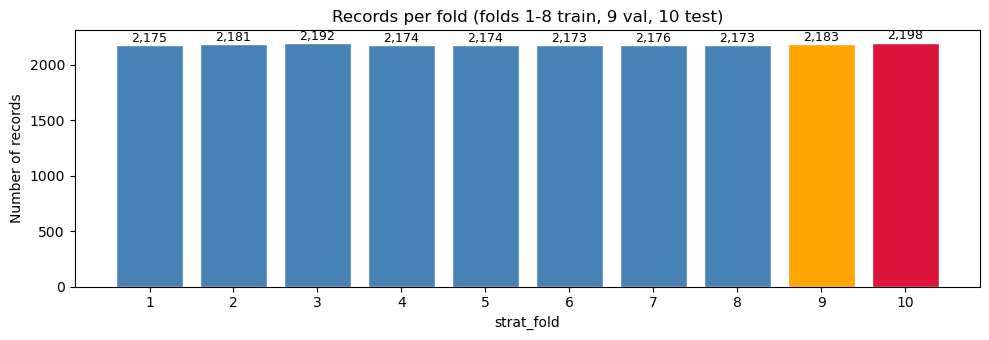

Train: 17,418 (79.9%)
Val  : 2,183 (10.0%)
Test : 2,198 (10.1%)


In [6]:
fold_counts = db['strat_fold'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 3.5))
colors = ['steelblue'] * 8 + ['orange', 'crimson']
bars = ax.bar(fold_counts.index, fold_counts.values, color=colors, edgecolor='white')
for bar, v in zip(bars, fold_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 30, f'{v:,}',
            ha='center', fontsize=9)
ax.set_xticks(fold_counts.index)
ax.set_xlabel('strat_fold')
ax.set_ylabel('Number of records')
ax.set_title('Records per fold (folds 1-8 train, 9 val, 10 test)')
plt.tight_layout()
plt.show()

train_n = (db['strat_fold'] <  9).sum()
val_n   = (db['strat_fold'] == 9).sum()
test_n  = (db['strat_fold'] == 10).sum()
total   = train_n + val_n + test_n
print(f'Train: {train_n:,} ({100*train_n/total:.1f}%)')
print(f'Val  : {val_n:,} ({100*val_n/total:.1f}%)')
print(f'Test : {test_n:,} ({100*test_n/total:.1f}%)')

## 4. Diagnostic labels: from SCP codes to 5 superclasses

`scp_statements.csv` maps each of the 71 SCP-ECG codes to a `diagnostic_class`.
We collapse those into the five PTB-XL **superclasses**:

| Superclass | Description |
|------------|-------------|
| `NORM` | Normal ECG |
| `MI`   | Myocardial Infarction |
| `STTC` | ST / T Change |
| `CD`   | Conduction Disturbance |
| `HYP`  | Hypertrophy |

An ECG can belong to multiple superclasses, so this is a **multi-label**
classification problem. Records without any diagnostic SCP code are dropped
because we have nothing to train on.

The mapping is implemented once in `src/preprocessing/label_utils.py` and reused by every
downstream notebook and dataset - we call it here rather than reimplementing it.

In [7]:
from src.preprocessing.label_utils import load_all_labels, SUPERCLASSES

Y = load_all_labels(
    db_path  = DATA_PATH + 'ptbxl_database.csv',
    scp_path = DATA_PATH + 'scp_statements.csv',
)
Y.head(3)[['scp_codes', 'superclass', 'label_vec', 'strat_fold']]

Records with valid labels: 21375
Class distribution:
  NORM: 9514 (44.5%)
  MI: 5469 (25.6%)
  STTC: 5108 (23.9%)
  CD: 4898 (22.9%)
  HYP: 2649 (12.4%)


,scp_codes,superclass,label_vec,strat_fold
ecg_id,,,,
1,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",[NORM],"[1.0, 0.0, 0.0, 0.0, 0.0]",3
2,"{'NORM': 80.0, 'SBRAD': 0.0}",[NORM],"[1.0, 0.0, 0.0, 0.0, 0.0]",2
3,"{'NORM': 100.0, 'SR': 0.0}",[NORM],"[1.0, 0.0, 0.0, 0.0, 0.0]",5


### 4.1 Class distribution (multi-label)

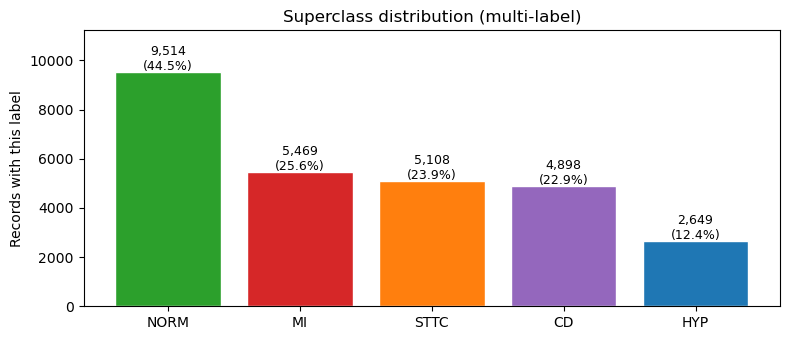

Records with exactly 1 label : 16,307 (76.3%)
Records with 2 labels        : 4,024 (18.8%)
Records with 3+ labels       : 1,044 (4.9%)


In [8]:
label_matrix = np.stack(Y['label_vec'].values)  # (N, 5)
class_counts = label_matrix.sum(axis=0).astype(int)
class_freq   = class_counts / len(Y)

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.bar(SUPERCLASSES, class_counts,
              color=['#2ca02c', '#d62728', '#ff7f0e', '#9467bd', '#1f77b4'],
              edgecolor='white')
for bar, c, f in zip(bars, class_counts, class_freq):
    ax.text(bar.get_x() + bar.get_width() / 2, c + 80,
            f'{c:,}\n({f*100:.1f}%)', ha='center', fontsize=9)
ax.set_ylabel('Records with this label')
ax.set_title('Superclass distribution (multi-label)')
ax.set_ylim(0, class_counts.max() * 1.18)
plt.tight_layout()
plt.show()

labels_per_record = label_matrix.sum(axis=1)
print(f'Records with exactly 1 label : {(labels_per_record == 1).sum():,} '
      f'({100*(labels_per_record == 1).mean():.1f}%)')
print(f'Records with 2 labels        : {(labels_per_record == 2).sum():,} '
      f'({100*(labels_per_record == 2).mean():.1f}%)')
print(f'Records with 3+ labels       : {(labels_per_record >= 3).sum():,} '
      f'({100*(labels_per_record >= 3).mean():.1f}%)')

### 4.2 Class imbalance and `pos_weight`

`HYP` is the rarest class at roughly 12% prevalence. In
`src/training/train_peft.py` the loss is `BCEWithLogitsLoss` with
`pos_weight=[1.0, 1.8, 1.8, 1.9, 3.5]` to compensate. Below we show the empirical
frequencies that motivate those weights.

In [9]:
for sc, c, f in zip(SUPERCLASSES, class_counts, class_freq):
    print(f'  {sc:5s} : {c:5,}  ({f*100:5.1f}%)')
print()
print('Implied inverse-frequency weights (normalised to NORM = 1.0):')
norm_freq = class_freq[SUPERCLASSES.index('NORM')]
for sc, f in zip(SUPERCLASSES, class_freq):
    print(f'  {sc:5s} : {norm_freq / f:.2f}')

  NORM  : 9,514  ( 44.5%)
  MI    : 5,469  ( 25.6%)
  STTC  : 5,108  ( 23.9%)
  CD    : 4,898  ( 22.9%)
  HYP   : 2,649  ( 12.4%)

Implied inverse-frequency weights (normalised to NORM = 1.0):
  NORM  : 1.00
  MI    : 1.74
  STTC  : 1.86
  CD    : 1.94
  HYP   : 3.59


## 5. Inspecting a single WFDB record

Each WFDB record is a `.dat` (binary samples) plus `.hea` (header) pair. We use
`wfdb.rdsamp()` to load both at once. The low-resolution record is a `(1000, 12)`
float array sampled at 100 Hz - 10 seconds across the standard 12 leads.

In [10]:
import wfdb

example_id = Y.index[0]
row = Y.loc[example_id]
signal, meta = wfdb.rdsamp(DATA_PATH + row['filename_lr'])

print(f'Record ecg_id    : {example_id}')
print(f'Signal shape     : {signal.shape}  (samples, leads)')
print(f'Sampling rate    : {meta["fs"]} Hz')
print(f'Duration         : {signal.shape[0] / meta["fs"]:.1f} s')
print(f'Leads            : {meta["sig_name"]}')
print(f'Units            : {meta["units"][0]} (all leads)')
print(f'SCP codes (raw)  : {row["scp_codes"]}')
print(f'Superclasses     : {row["superclass"]}')
print(f'Label vector     : {row["label_vec"]}')
print(f'Patient age/sex  : {row["age"]} / {["M", "F"][int(row["sex"])]}')
print(f'Fold             : {row["strat_fold"]}')

Record ecg_id    : 1
Signal shape     : (1000, 12)  (samples, leads)
Sampling rate    : 100 Hz
Duration         : 10.0 s
Leads            : ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Units            : mV (all leads)
SCP codes (raw)  : {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
Superclasses     : ['NORM']
Label vector     : [1.0, 0.0, 0.0, 0.0, 0.0]
Patient age/sex  : 56.0 / F
Fold             : 3


## 6. Visualisation

Three views of the same record:

1. All 12 leads stacked (overview).
2. A single lead at higher detail (waveform morphology).
3. A side-by-side comparison of a `NORM` vs an `MI` record on lead II - this is
   the contrast the downstream models will learn to detect.

Standard 12-lead grouping:
- **Limb leads:** I, II, III
- **Augmented limb leads:** aVR, aVL, aVF
- **Precordial leads:** V1, V2, V3, V4, V5, V6

### 6.1 All 12 leads

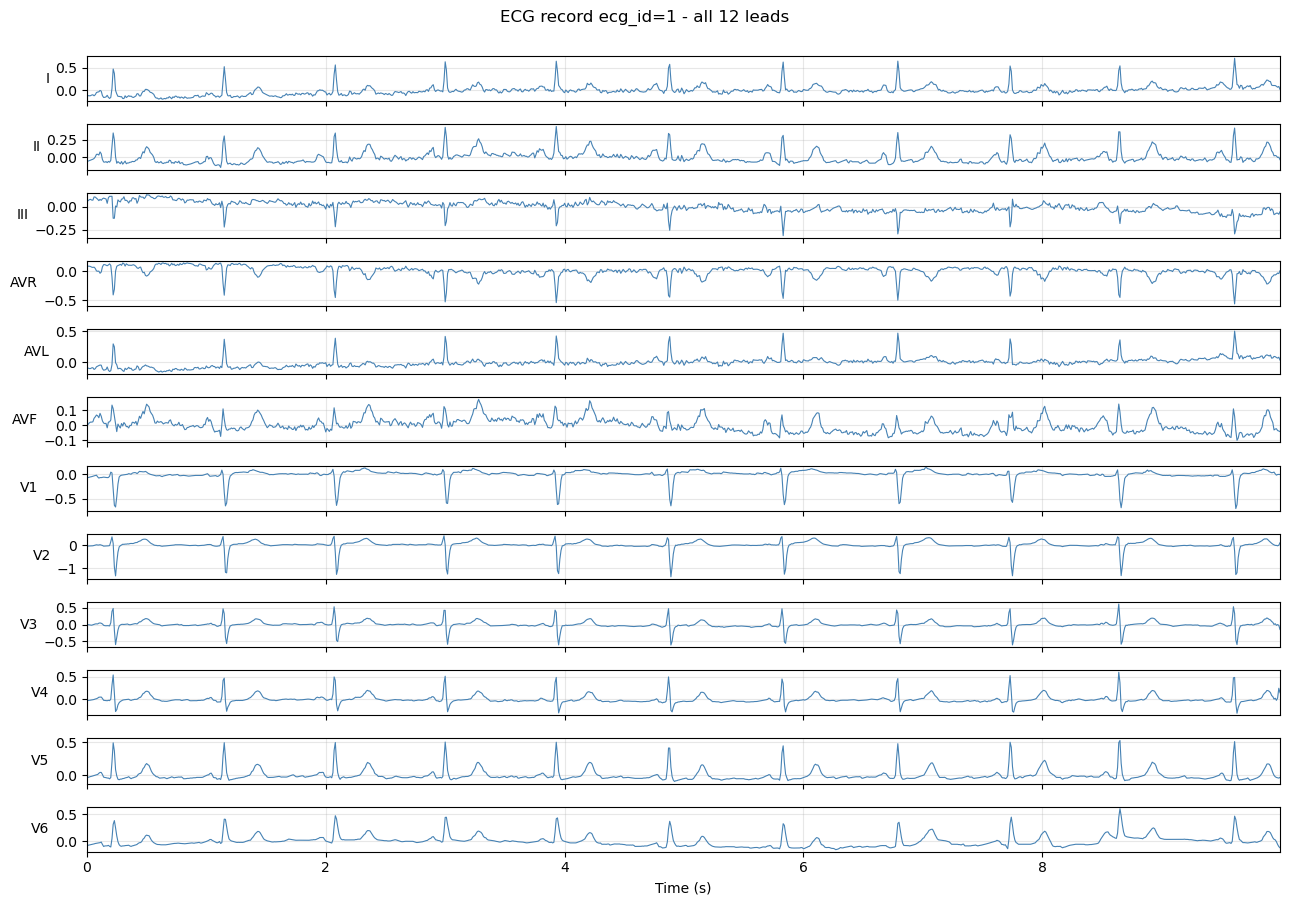

In [11]:
time_axis = np.arange(signal.shape[0]) / meta['fs']

fig, axes = plt.subplots(12, 1, figsize=(13, 9), sharex=True)
fig.suptitle(f'ECG record ecg_id={example_id} - all 12 leads', y=1.00)
for i, lead in enumerate(meta['sig_name']):
    axes[i].plot(time_axis, signal[:, i], linewidth=0.8, color='steelblue')
    axes[i].set_ylabel(lead, rotation=0, ha='right', va='center', fontsize=10)
    axes[i].grid(True, alpha=0.3)
    axes[i].margins(x=0)
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

### 6.2 Single lead detail (lead II)

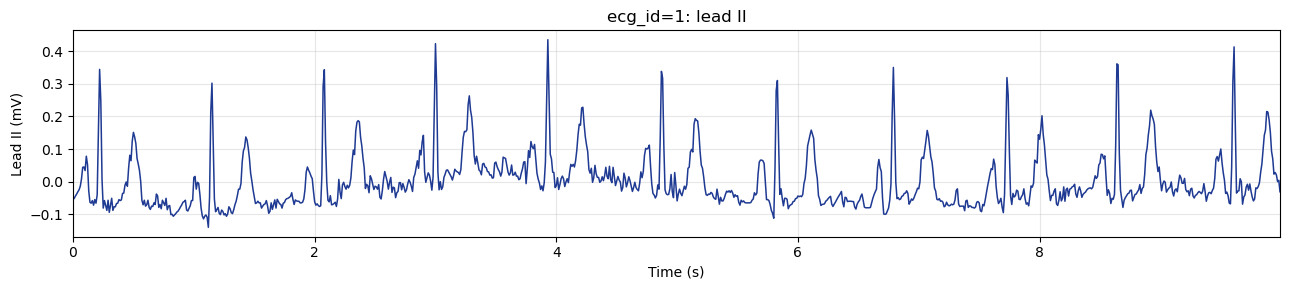

Lead II amplitude statistics (raw, before preprocessing):
  min = -0.140 mV
  max = +0.435 mV
  mean = +0.001 mV
  std = 0.083 mV


In [12]:
lead_idx  = meta['sig_name'].index('II')
lead_name = meta['sig_name'][lead_idx]

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(time_axis, signal[:, lead_idx], linewidth=1.1, color='#1f3a93')
ax.set_xlabel('Time (s)')
ax.set_ylabel(f'Lead {lead_name} ({meta["units"][lead_idx]})')
ax.set_title(f'ecg_id={example_id}: lead {lead_name}')
ax.grid(True, alpha=0.3)
ax.margins(x=0)
plt.tight_layout()
plt.show()

x = signal[:, lead_idx]
print(f'Lead {lead_name} amplitude statistics (raw, before preprocessing):')
print(f'  min = {x.min():+.3f} mV')
print(f'  max = {x.max():+.3f} mV')
print(f'  mean = {x.mean():+.3f} mV')
print(f'  std = {x.std():.3f} mV')

### 6.3 NORM vs MI side-by-side

We pick one confidently-labelled record per class. For `MI` we look for a record
whose dominant SCP code has likelihood 100 (the diagnosis is confirmed) and which
is **not** also labelled `NORM`.

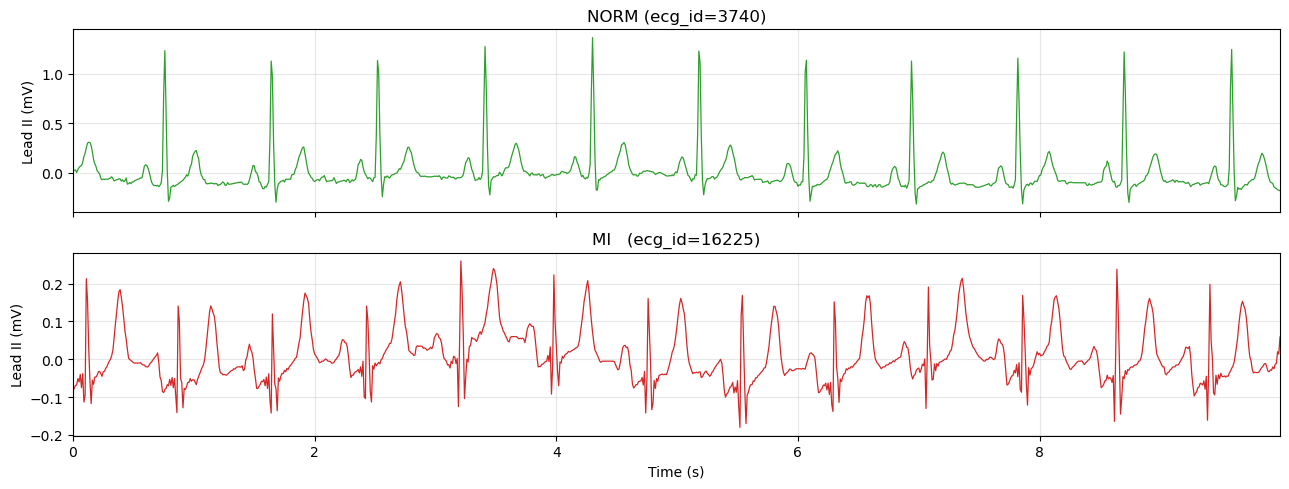

In [18]:
# Curated representative examples (single-label, test/val fold, textbook SCP codes)
CURATED_EXAMPLES = {
    'NORM': 3740,   
    'MI':   16225,  
    'STTC': 8834,    
    'CD':   3699,   
    'HYP':  534,   
}

norm_id = CURATED_EXAMPLES['NORM']
mi_id   = CURATED_EXAMPLES['MI']

fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
for ax, eid, color, title in [
    (axes[0], norm_id, '#2ca02c', f'NORM (ecg_id={norm_id})'),
    (axes[1], mi_id,   '#d62728', f'MI   (ecg_id={mi_id})'),
]:
    sig, m = wfdb.rdsamp(DATA_PATH + Y.loc[eid, 'filename_lr'])
    t = np.arange(sig.shape[0]) / m['fs']
    lead_ii = m['sig_name'].index('II')
    ax.plot(t, sig[:, lead_ii], linewidth=0.9, color=color)
    ax.set_ylabel('Lead II (mV)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.margins(x=0)
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

### 6.4 One example per superclass (demo gallery)

We also pick a representative record for each of the five superclasses. The
`ecg_id`s are saved to `results/01_data_exploration/example_records.json` so the
Streamlit app can load the exact same set without re-scanning the dataset.

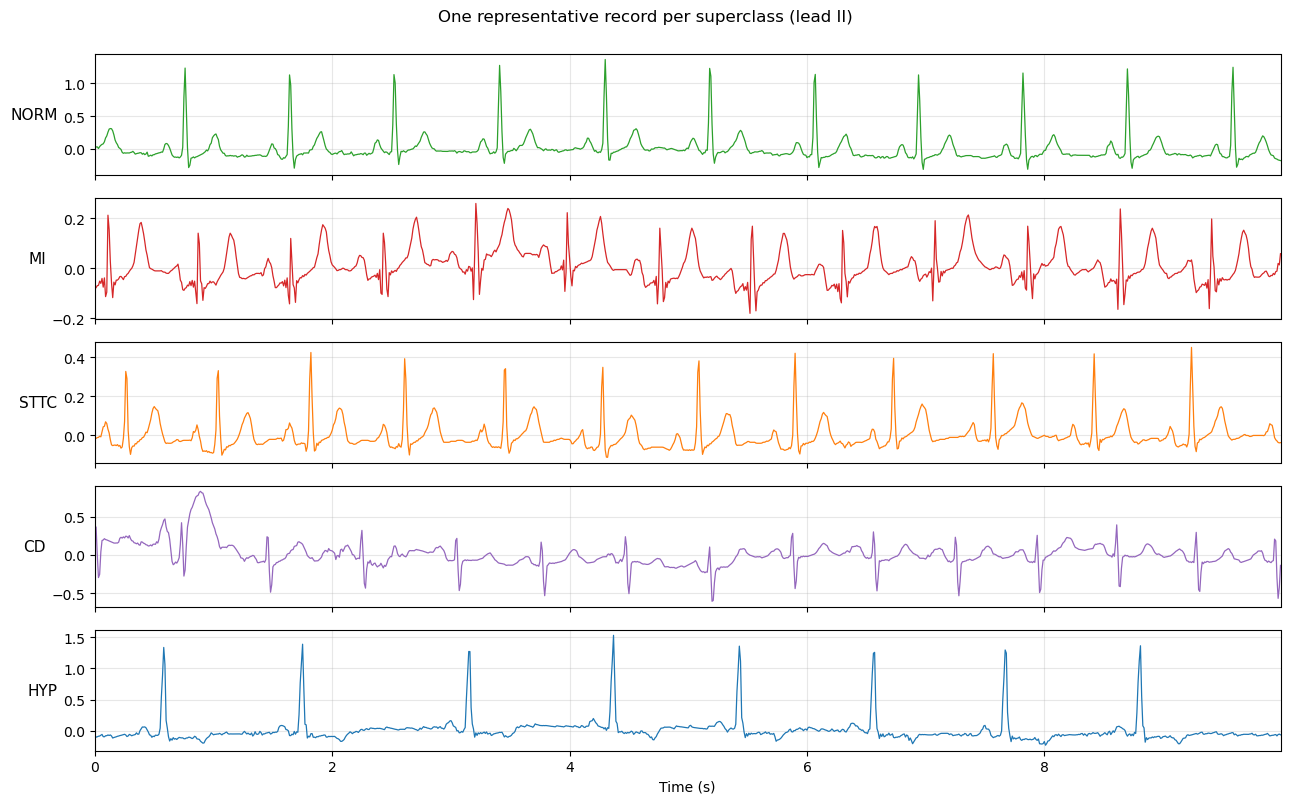

  NORM  -> ecg_id = 3740  (fold 10)
  MI    -> ecg_id = 16225  (fold 10)
  STTC  -> ecg_id = 8834  (fold 10)
  CD    -> ecg_id = 3699  (fold 10)
  HYP   -> ecg_id = 534  (fold 10)


In [19]:
examples = CURATED_EXAMPLES

fig, axes = plt.subplots(len(examples), 1, figsize=(13, 1.6 * len(examples)),
                         sharex=True)
palette = ['#2ca02c', '#d62728', '#ff7f0e', '#9467bd', '#1f77b4']
for ax, (sc, eid), color in zip(axes, examples.items(), palette):
    sig, m = wfdb.rdsamp(DATA_PATH + Y.loc[eid, 'filename_lr'])
    t = np.arange(sig.shape[0]) / m['fs']
    lead_ii = m['sig_name'].index('II')
    ax.plot(t, sig[:, lead_ii], linewidth=0.9, color=color)
    ax.set_ylabel(sc, rotation=0, ha='right', va='center', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.margins(x=0)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('One representative record per superclass (lead II)', y=1.00)
plt.tight_layout()
plt.show()

for sc, eid in examples.items():
    print(f'  {sc:5s} -> ecg_id = {eid}  (fold {int(Y.loc[eid, "strat_fold"])})')

## 7. Reproducible train / val / test split

We materialise the masks based on `strat_fold` (the same logic encoded in
`src/preprocessing/dataset.py`) and check that the class balance stays similar across
splits - any large drift would warn us that the test set isn't representative.

In [15]:
train_mask = Y['strat_fold'] <  9
val_mask   = Y['strat_fold'] == 9
test_mask  = Y['strat_fold'] == 10

split_table = pd.DataFrame(
    {
        sc: [
            int(label_matrix[train_mask.values, i].sum()),
            int(label_matrix[val_mask.values,   i].sum()),
            int(label_matrix[test_mask.values,  i].sum()),
        ]
        for i, sc in enumerate(SUPERCLASSES)
    },
    index=['train', 'val', 'test'],
)
split_table['total_records'] = [int(train_mask.sum()), int(val_mask.sum()), int(test_mask.sum())]
split_table

,NORM,MI,STTC,CD,HYP,total_records
train,7596,4379,4087,3907,2119,17073
val,955,540,515,495,268,2145
test,963,550,506,496,262,2157


In [16]:
# Per-split prevalence (sanity check: should be similar across rows)
split_freq = split_table[SUPERCLASSES].div(split_table['total_records'], axis=0)
(split_freq * 100).round(1).astype(str) + '%'

,NORM,MI,STTC,CD,HYP
train,44.5%,25.6%,23.9%,22.9%,12.4%
val,44.5%,25.2%,24.0%,23.1%,12.5%
test,44.6%,25.5%,23.5%,23.0%,12.1%


## 8. Persist artifacts for downstream notebooks and the Streamlit app

We write to `results/01_data_exploration/`:

- `dataset_summary.json` - record counts, class counts/frequencies, split sizes,
  and PTB-XL version metadata. Imported by the Streamlit landing page.
- `example_records.json` - one representative `ecg_id` per superclass for demos.
- `figures/superclass_distribution.png`, `figures/example_per_class.png` -
  publication-quality figures used in the methodology section of the report.

We do **not** save a processed labels parquet here - downstream notebooks call
`load_all_labels()` directly, which keeps the canonical mapping in one place
(`src/preprocessing/label_utils.py`).

In [20]:
import json

OUT_DIR = Path(RESULTS_PATH) / '01_data_exploration'
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

summary = {
    'dataset': 'PTB-XL v1.0.3',
    'sampling_rate_hz': int(CFG['data']['sampling_rate']),
    'n_records_raw': int(len(db)),
    'n_records_labelled': int(len(Y)),
    'n_patients': int(Y['patient_id'].nunique()),
    'superclasses': list(SUPERCLASSES),
    'class_counts': {sc: int(c) for sc, c in zip(SUPERCLASSES, class_counts)},
    'class_freq':   {sc: float(f) for sc, f in zip(SUPERCLASSES, class_freq)},
    'splits': {
        'train': int(train_mask.sum()),
        'val':   int(val_mask.sum()),
        'test':  int(test_mask.sum()),
    },
    'pos_weight_used_in_training': [1.0, 1.8, 1.8, 1.9, 3.5],
}
(OUT_DIR / 'dataset_summary.json').write_text(json.dumps(summary, indent=2))

examples_payload = {
    sc: {
        'ecg_id': int(eid),
        'filename_lr': Y.loc[eid, 'filename_lr'],
        'strat_fold': int(Y.loc[eid, 'strat_fold']),
        'age': float(Y.loc[eid, 'age']) if Y.loc[eid, 'age'] < 300 else None,
        'sex': ['M', 'F'][int(Y.loc[eid, 'sex'])],
        'scp_codes': {k: float(v) for k, v in Y.loc[eid, 'scp_codes'].items()},
    }
    for sc, eid in examples.items()
}
(OUT_DIR / 'example_records.json').write_text(json.dumps(examples_payload, indent=2))

# Re-save the two key figures as standalone files
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(SUPERCLASSES, class_counts,
       color=['#2ca02c', '#d62728', '#ff7f0e', '#9467bd', '#1f77b4'],
       edgecolor='white')
for i, (c, f) in enumerate(zip(class_counts, class_freq)):
    ax.text(i, c + 80, f'{c:,}\n({f*100:.1f}%)', ha='center', fontsize=9)
ax.set_ylabel('Records with this label')
ax.set_title('PTB-XL superclass distribution (multi-label)')
ax.set_ylim(0, class_counts.max() * 1.18)
plt.tight_layout()
fig.savefig(FIG_DIR / 'superclass_distribution.png', dpi=150, bbox_inches='tight')
plt.close(fig)

fig, axes = plt.subplots(len(examples), 1, figsize=(13, 1.6 * len(examples)),
                         sharex=True)
for ax, (sc, eid), color in zip(axes, examples.items(), palette):
    sig, m = wfdb.rdsamp(DATA_PATH + Y.loc[eid, 'filename_lr'])
    t = np.arange(sig.shape[0]) / m['fs']
    lead_ii = m['sig_name'].index('II')
    ax.plot(t, sig[:, lead_ii], linewidth=0.9, color=color)
    ax.set_ylabel(sc, rotation=0, ha='right', va='center', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.margins(x=0)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('One representative PTB-XL record per superclass (lead II)', y=1.00)
plt.tight_layout()
fig.savefig(FIG_DIR / 'example_per_class.png', dpi=150, bbox_inches='tight')
plt.close(fig)

print('Artifacts written:')
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        print(f'  {p.relative_to(Path(RESULTS_PATH))}  ({p.stat().st_size / 1024:.1f} KB)')

Artifacts written:
  01_data_exploration\dataset_summary.json  (0.7 KB)
  01_data_exploration\example_records.json  (1.1 KB)
  01_data_exploration\figures\example_per_class.png  (290.5 KB)
  01_data_exploration\figures\superclass_distribution.png  (47.8 KB)
